<a href="https://colab.research.google.com/github/vinakumarreddy/Data-Science/blob/dsa/RNNLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os

In [2]:
path = kagglehub.dataset_download('snap/amazon-fine-food-reviews')
csv_file = os.path.join(path,'Reviews.csv')
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.columns.to_list()

['Id',
 'ProductId',
 'UserId',
 'ProfileName',
 'HelpfulnessNumerator',
 'HelpfulnessDenominator',
 'Score',
 'Time',
 'Summary',
 'Text']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [7]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [8]:
df_cleaned =  df[['Text','Score']].dropna()
df_cleaned.head()


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [9]:
value_counts = df_cleaned['Score'].value_counts()
print(value_counts)

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64


In [10]:
for score,count in value_counts.items():
  percentage = (count/len(df_cleaned))*100
  print(f'Score: {score}, Count: {count}, Percentage: {percentage:.2f}%')

Score: 5, Count: 363122, Percentage: 63.88%
Score: 4, Count: 80655, Percentage: 14.19%
Score: 1, Count: 52268, Percentage: 9.19%
Score: 3, Count: 42640, Percentage: 7.50%
Score: 2, Count: 29769, Percentage: 5.24%


In [11]:
scores=[1,2,3,4,5]
for score in scores:
  sample = df_cleaned[df_cleaned['Score']==score].iloc[0]
  print(f'star -{score} review -{sample[:200]}')

star -1 review -Text     Product arrived labeled as Jumbo Salted Peanut...
Score                                                    1
Name: 1, dtype: object
star -2 review -Text     If you are looking for the secret ingredient i...
Score                                                    2
Name: 3, dtype: object
star -3 review -Text     This seems a little more wholesome than some o...
Score                                                    3
Name: 45, dtype: object
star -4 review -Text     This is a confection that has been around a fe...
Score                                                    4
Name: 2, dtype: object
star -5 review -Text     I have bought several of the Vitality canned d...
Score                                                    5
Name: 0, dtype: object


In [12]:
df_cleaned['text_length'] = df_cleaned['Text'].str.len()
df_cleaned['word_count']=df_cleaned['Text'].str.split().str.len()

In [13]:
df_cleaned.head(2)

,Text,Score,text_length,word_count
0,I have bought several of the Vitality canned d...,5,263,48
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31


#class **imbalance**

In [14]:
df_binary = df_cleaned[df_cleaned['Score']!=3]
df_binary.head()

,Text,Score,text_length,word_count
0,I have bought several of the Vitality canned d...,5,263,48
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31
2,This is a confection that has been around a fe...,4,509,94
3,If you are looking for the secret ingredient i...,2,219,41
4,Great taffy at a great price. There was a wid...,5,140,27


In [15]:
df_binary.value_counts('Score')

,count
Score,
5,363122
4,80655
1,52268
2,29769


In [16]:
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)
df_binary.head()

/tmp/ipython-input-869236839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)


,Text,Score,text_length,word_count,sentiment
0,I have bought several of the Vitality canned d...,5,263,48,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,31,0
2,This is a confection that has been around a fe...,4,509,94,1
3,If you are looking for the secret ingredient i...,2,219,41,0
4,Great taffy at a great price. There was a wid...,5,140,27,1


In [17]:
print(f"Negative review(1-2) :{sum(df_binary['sentiment']==0):,}")
print(f"Positive review(4-5) :{sum(df_binary['sentiment']==1):,}")

Negative review(1-2) :82,037
Positive review(4-5) :443,777


In [18]:
df_binary['sentiment'].value_counts(normalize=True)*100

,proportion
sentiment,
1,84.398095
0,15.601905


In [19]:
from sklearn.utils import resample
df_majority = df_binary[df_binary['sentiment']==0]
df_minority = df_binary[df_binary['sentiment']==1]

In [20]:
df_minority.shape

(443777, 5)

In [21]:
df_majority.shape

(82037, 5)

In [22]:
df_majority_downsampled = resample(df_minority,
                                  replace=False,
                                  n_samples=len(df_majority),
                                  random_state=42)

In [23]:
df_majority_downsampled.shape

(82037, 5)

In [24]:
df_majority.shape

(82037, 5)

In [25]:
df_cleaned = pd.concat([df_majority_downsampled,df_majority])
df_cleaned.head()

,Text,Score,text_length,word_count,sentiment
45288,I have started every morning for the last 7 mo...,5,504,95,1
335756,Thank goodness this pasta makes life for a glu...,5,414,71,1
318554,I am the type of person who gets tired and sta...,5,339,71,1
105294,The flavor of these is just amazing. They are ...,5,690,124,1
92364,I have been using Coffee People Donut Shop for...,5,674,127,1


In [26]:
df_cleaned = df_cleaned.sample(frac=1).reset_index(drop=True)

In [27]:
df_cleaned.head()

,Text,Score,text_length,word_count,sentiment
0,"Smooth implies weak, robust implies bitter, ne...",5,157,29,1
1,This cereal has changed for the gross. I didn...,1,486,87,0
2,Do Not Buy this unless you love the wonderful ...,1,142,25,0
3,"This jerky is; tough, fat, has gristle, and do...",1,174,32,0
4,I thought these would be more like the cookies...,1,112,22,0


In [28]:
print(f'Negative review(1-2) :{sum(df_cleaned["sentiment"]==0):,}')
print(f'Positive review(4-5) :{sum(df_cleaned["sentiment"]==1):,}')

Negative review(1-2) :82,037
Positive review(4-5) :82,037


In [29]:
sample_min = min(50000,len(df_cleaned))
df_cleaned1 = df_cleaned.sample(n=sample_min,random_state=42)

In [30]:
print(f'Negative review(1-2) :{sum(df_cleaned1["sentiment"]==0):,}')
print(f'Positive review(4-5) :{sum(df_cleaned1["sentiment"]==1):,}')

Negative review(1-2) :25,043
Positive review(4-5) :24,957


In [31]:
df_cleaned1

,Text,Score,text_length,word_count,sentiment
55281,Got this for my husband for Christmas. They w...,5,131,23,1
44091,"For a bit, Amazon improved the packaging on th...",2,189,32,0
38501,The crisp texture of these PopChips is very ap...,4,648,115,1
22400,I ordered this for my boyfriend because he has...,4,304,59,1
163757,I ordered 3 boxes of 18 each.............and o...,1,241,42,0
...,...,...,...,...,...
13179,I was skeptical thinking this tea might not ha...,4,137,25,1
60085,"My cats are small, furry gravy-loving demons a...",2,240,43,0
118830,These aren't real k-cups but the knock-off mes...,1,126,21,0
4519,I was so excited to try these Stonewall Kitche...,1,1160,214,0


In [32]:
scores=[1,2,4,5]
for score in scores:
  sample = df_cleaned1[df_cleaned1['Score']==score].iloc[0]
  print(f'star -{score} review -{sample[:200]}')

star -1 review -Text           I ordered 3 boxes of 18 each.............and o...
Score                                                          1
text_length                                                  241
word_count                                                    42
sentiment                                                      0
Name: 163757, dtype: object
star -2 review -Text           For a bit, Amazon improved the packaging on th...
Score                                                          2
text_length                                                  189
word_count                                                    32
sentiment                                                      0
Name: 44091, dtype: object
star -4 review -Text           The crisp texture of these PopChips is very ap...
Score                                                          4
text_length                                                  648
word_count                                          

Clean the text
1)convert into lowercase
2)remove the special **characters**

In [33]:
#function to remove and we will implement RNN And LSTM

In [34]:
import re
def clean_data(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]','',text)
  text = ' '.join(text.split())
  return text

In [35]:
df_cleaned1['Text']=df_cleaned1['Text'].apply(clean_data)
df_cleaned1.head()

,Text,Score,text_length,word_count,sentiment
55281,got this for my husband for christmas they wer...,5,131,23,1
44091,for a bit amazon improved the packaging on the...,2,189,32,0
38501,the crisp texture of these popchips is very ap...,4,648,115,1
22400,i ordered this for my boyfriend because he has...,4,304,59,1
163757,i ordered boxes of eachand opened one box to f...,1,241,42,0


In [36]:
df_cleaned1.shape

(50000, 5)

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
Max_feature=10000 #no. of vocabulary
Max_len=100 #number of words
x=df_cleaned1['Text']
y=df_cleaned1['sentiment']

tokenizer = Tokenizer(num_words=Max_feature,oov_token='<oov>')
tokenizer.fit_on_texts(x)#frequency of each vocabulary
x_sequence=tokenizer.texts_to_sequences(x)
#add padding for the sequences
x_padding=pad_sequences(x_sequence,maxlen=Max_len,padding='post',truncating='post')
# oov out of token it will take of handles unknown words
#now we will find sequence of all the frequencies we have

In [38]:
print((x[0][:100]))
print(x_sequence[0][:20])
print(x_padding[0].shape)

smooth implies weak robust implies bitter neither are true as to the negative but true as to how won
[122, 9, 12, 14, 434, 12, 864, 21, 61, 1507, 1118, 4, 56, 8, 397, 68, 34, 16, 15, 957]
(100,)


In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_padding,y,test_size=0.2,random_state=42,stratify=y)

In [40]:
print(x_train.shape[1])
y_test.shape

100


(10000,)

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_model():
    model = Sequential([
        Embedding(input_dim=Max_feature, output_dim=128, input_length=x_train.shape[1]),

        SimpleRNN(units=128, activation='tanh',dropout=0.2,recurrent_dropout=0.2),

        Dense(units=64, activation='relu'),

        Dropout(0.5),

        Dense(units=1, activation='sigmoid')
    ])

    return model


rnn_model = create_model()

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
x_train.shape

(40000, 100)

In [44]:
y_train.shape

(40000,)

In [45]:
x_test.shape,y_test.shape

((10000, 100), (10000,))

In [75]:
rnn_history = rnn_model.fit(x_train,y_train,epochs=5,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 67s 63ms/step - accuracy: 0.5000 - loss: 0.7173 - val_accuracy: 0.5004 - val_loss: 0.6929
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.5111 - loss: 0.6971 - val_accuracy: 0.5100 - val_loss: 0.6950
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.5069 - loss: 0.6947 - val_accuracy: 0.5182 - val_loss: 0.6913
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.5172 - loss: 0.6905 - val_accuracy: 0.5519 - val_loss: 0.6771
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.5578 - loss: 0.6718 - val_accuracy: 0.5365 - val_loss: 0.6872


## Analyze Current Model Performance

### Subtask:
Review the training history (loss and accuracy for both training and validation sets) in more detail to identify patterns like overfitting or underfitting that can guide further improvements.


**Reasoning**:
To analyze the training history, I need to access the history attribute of the `rnn_history` object, which contains the loss, accuracy, validation loss, and validation accuracy for each epoch. Printing this will allow for examination of learning patterns.



In [47]:
print(rnn_history.history)


{'accuracy': [0.5142499804496765, 0.523062527179718, 0.5478125214576721, 0.5513749718666077, 0.554562509059906], 'loss': [4.339883804321289, 5.28085994720459, 7.260407447814941, 7.205081939697266, 7.153586387634277], 'val_accuracy': [0.500374972820282, 0.5023750066757202, 0.6107500195503235, 0.6107500195503235, 0.6107500195503235], 'val_loss': [0.8168858885765076, 35863257939968.0, 14855748714496.0, 14855748714496.0, 14855748714496.0]}


In [64]:
def create_improved_model():
  model = Sequential([
      Embedding(input_dim=Max_feature, output_dim=256),
      LSTM(units=128, return_sequences=False),
      Dense(units=64, activation='relu'),
      Dropout(0.2),
      Dense(units=1, activation='sigmoid')
  ])
  return model

improved_model = create_improved_model()
improved_model.build(input_shape=(None, Max_len)) # Explicitly build the model
improved_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
improved_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,441 (10.55 MB)

 Trainable params: 2,765,441 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
Now that the improved model architecture is defined and correctly summarized, I need to implement the `EarlyStopping` callback as specified in the subtask. This will monitor the `val_accuracy` and stop training if it doesn't improve for 5 consecutive epochs, helping to prevent overfitting.



In [61]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
print("EarlyStopping callback defined.")

EarlyStopping callback defined.


**Reasoning**:
Now that the improved model and `EarlyStopping` callback are defined, I will retrain the model using the training data (`x_train`, `y_train`) and validate it with `x_test` and `y_test`, incorporating the `early_stopping` callback to prevent overfitting.



In [65]:
improved_history = improved_model.fit(x_train, y_train, epochs=2, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 350s 278ms/step - accuracy: 0.5412 - loss: 0.6847 - val_accuracy: 0.7187 - val_loss: 0.6044
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 362s 262ms/step - accuracy: 0.8134 - loss: 0.4330 - val_accuracy: 0.8798 - val_loss: 0.2993


In [ ]:
# history = improved_model.fit(x_train,y_train,epochs=3,batch_size=32,validation_split=0.2,verbose=1)

In [76]:
final_accuracy = improved_history.history['accuracy'][-1]
print(f"Final Accuracy: {final_accuracy}")

Final Accuracy: 0.8443999886512756


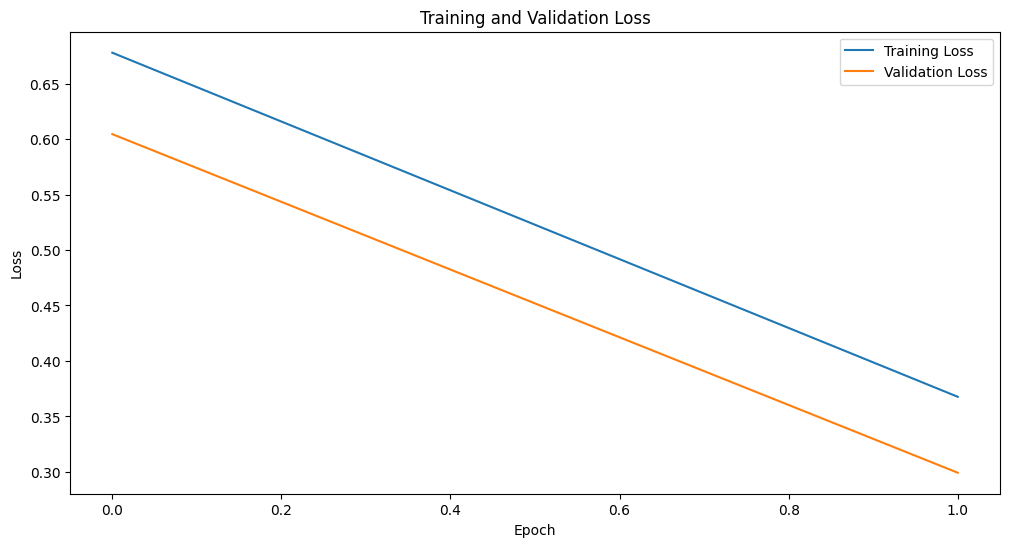

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(improved_history.history['loss'],label='Training Loss')
plt.plot(improved_history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [78]:
param_grid = {
    'model_type':['rnn','lstm'],
    'embedding_dim':[64,128],
    'units':[32,64,128],
    'dropout_rate':[0.20,0.30],
    'learning_rate':[0.001,0.01]
}

In [80]:
for param,value in param_grid.items():
  print(f'{param} : {value}')
  total_combination = 1
  for val in value:
    total_combination *= len(value)
  print(  f'total combination for {param} is {total_combination}')

model_type : ['rnn', 'lstm']
total combination for model_type is 4
embedding_dim : [64, 128]
total combination for embedding_dim is 4
units : [32, 64, 128]
total combination for units is 27
dropout_rate : [0.2, 0.3]
total combination for dropout_rate is 4
learning_rate : [0.001, 0.01]
total combination for learning_rate is 4


In [81]:
def create_model_with_params(model_type='rnn',embedding_dim=128,units=64,dropout_rate=0.2,learning_rate=0.001):
  model = Sequential([
      Embedding(Max_feature,embedding_dim,input_length=Max_len)
  ])
  if model_type=='rnn':
    model.add(SimpleRNN(units=units,activation='tanh',dropout=dropout_rate,recurrent_dropout=dropout_rate))
  else:
    model.add(LSTM(units=units,return_sequences=False,dropout=dropout_rate,recurrent_dropout=dropout_rate))
  model.add(Dropout(dropout_rate))
  model.add(Dense(32,activation='relu'))
  model.add(Dense(units=1,activation='sigmoid'))
  model.compile(optimizers=Adam(learning_rate=learning_rate),loss='binary_crossentropy',metrics=['accuracy'])
  return model

In [83]:
import pickle
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(improved_history, f)
